<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/Custom_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flow:

Imports

Dataset load

CNN define

Train

Accuracy print

Graph

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [5]:
# =====================
# 1. IMPORTS
# =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [6]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

In [7]:
train_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/train",transform=transform)
val_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/val",transform=transform)

In [8]:
train_loader= DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# =====================
# 3. MODEL
# =====================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*8*8,256), nn.ReLU(),
            nn.Linear(256,200)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = CNN().to(device)

In [28]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []
val_accuracies = [] # Initialize list to store validation accuracies

for epoch in range(8):
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # Calculate validation accuracy after each epoch
    model.eval() # Set model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy) # Store the accuracy
    print(f"Epoch {epoch+1}, Validation Accuracy: {accuracy:.2f}%")

Epoch 1, Loss: 8024.1631
Epoch 1, Validation Accuracy: 0.51%
Epoch 2, Loss: 7865.4949
Epoch 2, Validation Accuracy: 1.04%
Epoch 3, Loss: 7719.5574
Epoch 3, Validation Accuracy: 0.69%
Epoch 4, Loss: 7570.8003
Epoch 4, Validation Accuracy: 0.58%
Epoch 5, Loss: 7430.3721
Epoch 5, Validation Accuracy: 0.33%
Epoch 6, Loss: 7306.9416
Epoch 6, Validation Accuracy: 0.55%
Epoch 7, Loss: 7167.2904
Epoch 7, Validation Accuracy: 0.83%
Epoch 8, Loss: 7066.7381
Epoch 8, Validation Accuracy: 0.48%


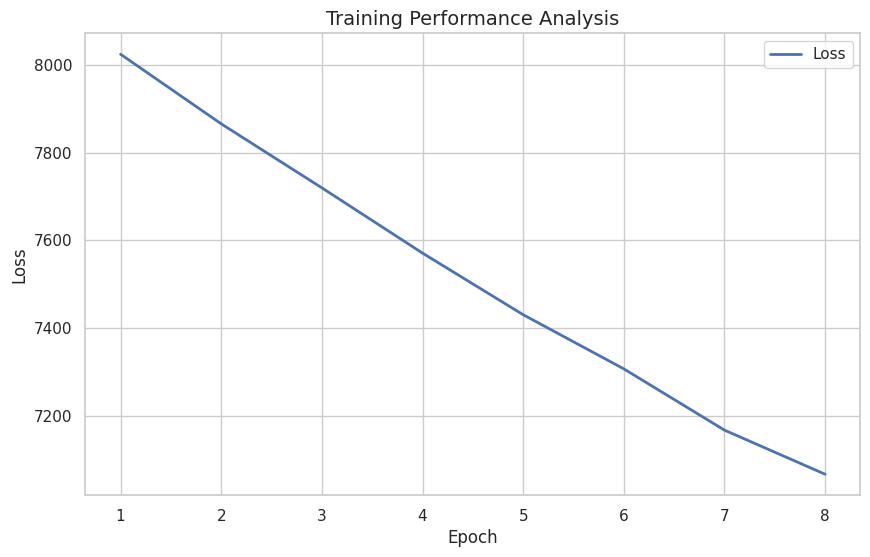

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'losses' from the previous cell is available for train_losses
# and 'epoch' variable from previous cell is available for total epochs (epoch + 1)

num_epochs = len(losses)
epochs_range = list(range(1, num_epochs + 1))

df = pd.DataFrame({
    "Epoch": epochs_range,
    "Loss": losses
})

plt.figure(figsize=(10,6))

sns.lineplot(data=df, x="Epoch", y="Loss", label="Loss", linewidth=2)

plt.title("Training Performance Analysis", fontsize=14)
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

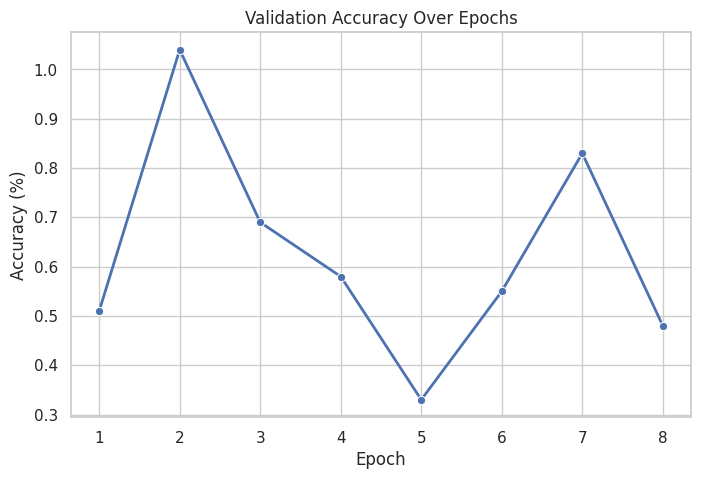

In [33]:
plt.figure(figsize=(8,5))

sns.lineplot(x=epochs_range, y=val_accuracies, marker="o", linewidth=2)

plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(True)
plt.show()

In [34]:
# =====================
# 6. ACCURACY
# =====================
model.eval()
correct, total = 0,0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs,1)
        total += labels.size(0)
        correct += (pred==labels).sum().item()
print("Accuracy:", 100*correct/total)


Accuracy: 0.46


In [35]:
import os
os.makedirs("outputs/cnn", exist_ok=True)

torch.save(model.state_dict(), "outputs/cnn/model.pth")
print("Model Saved ✅")

Model Saved ✅
